In [1]:
suppressWarnings(suppressMessages({
    library(Seurat)
    library(tidyverse)
}))

In [2]:
# read anno rds
data_seurat <- readRDS("../data/anno/data_anno.rds")

# read genus
df_genus <- t(read.table("../data/test/outs/test_filtered_UMI_matrix.tsv.gz", sep="\t", row.names = 1, header = T))
df_genus <- df_genus[ colnames(data_seurat),]  # match RNA barcode
df_genus <- df_genus[, colSums(df_genus)>0]   # filter 0 genus

data_seurat$total_genus <- rowSums(df_genus)
data_seurat@meta.data <- cbind.data.frame(data_seurat@meta.data, df_genus)

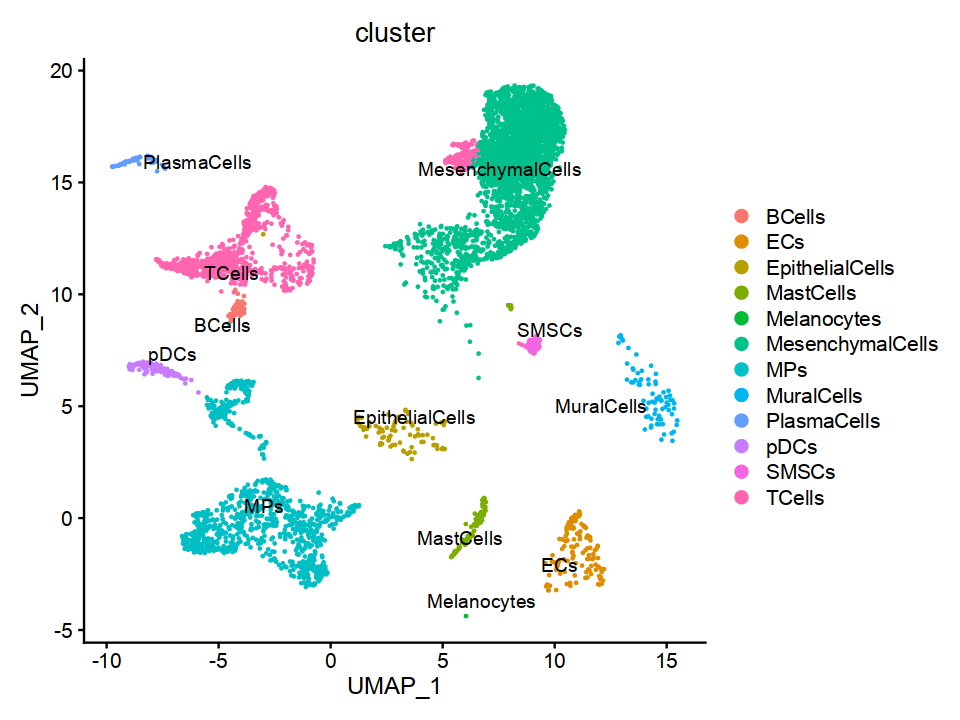

In [3]:
# plot cluster
options(repr.plot.height = 6, repr.plot.width = 8)
DimPlot(data_seurat, group.by = "cluster", label = T, repel = T)

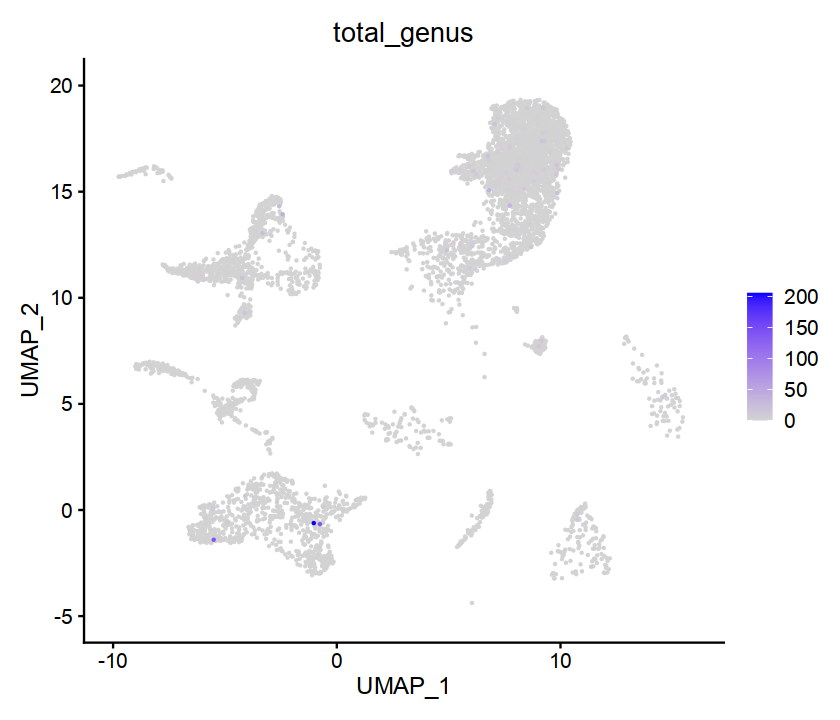

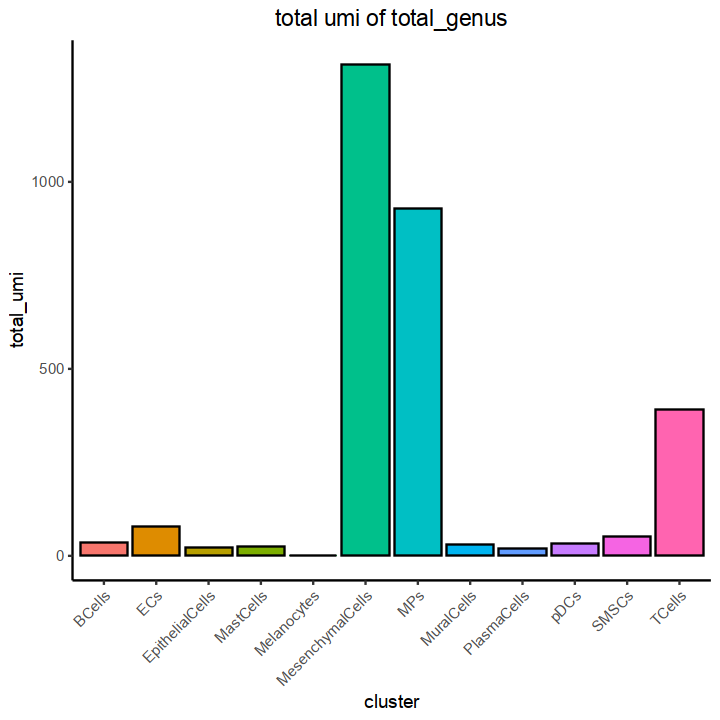

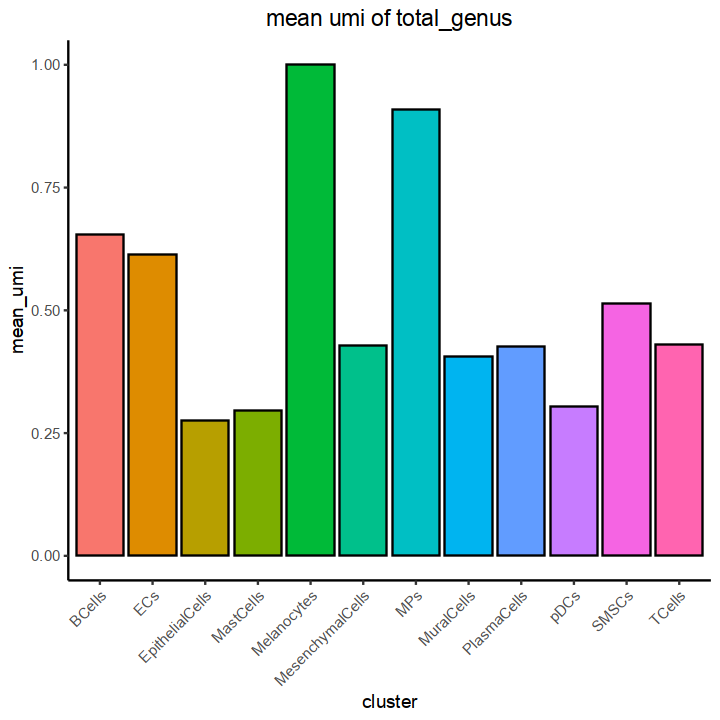

In [4]:
# total genus umi
options(repr.plot.height = 6, repr.plot.width = 7)
FeaturePlot(data_seurat, features = "total_genus", pt.size = 0.2, order = T)

# total umi
options(repr.plot.height = 6, repr.plot.width = 6)
data_seurat@meta.data %>% 
    group_by(cluster) %>%
    summarise(total_umi = sum(total_genus)) %>%
    ggplot(aes(x=cluster, y=total_umi, fill=cluster)) +
        geom_bar(color="black", stat = "identity", position = position_dodge()) +
        ggtitle("total umi of total_genus") +
        theme_classic() + 
        theme(axis.text.x = element_text(angle = 45, hjust = 1,vjust = 1), 
              plot.title = element_text(hjust = 0.5), 
              legend.position = "none")

# mean umi
data_seurat@meta.data %>% 
    group_by(cluster) %>%
    summarise(mean_umi = mean(total_genus)) %>%
    ggplot(aes(x=cluster, y=mean_umi, fill=cluster)) +
        geom_bar(color="black", stat = "identity", position = position_dodge()) +
        ggtitle("mean umi of total_genus") +
        theme_classic() + 
        theme(axis.text.x = element_text(angle = 45, hjust = 1,vjust = 1), 
              plot.title = element_text(hjust = 0.5), 
              legend.position = "none")

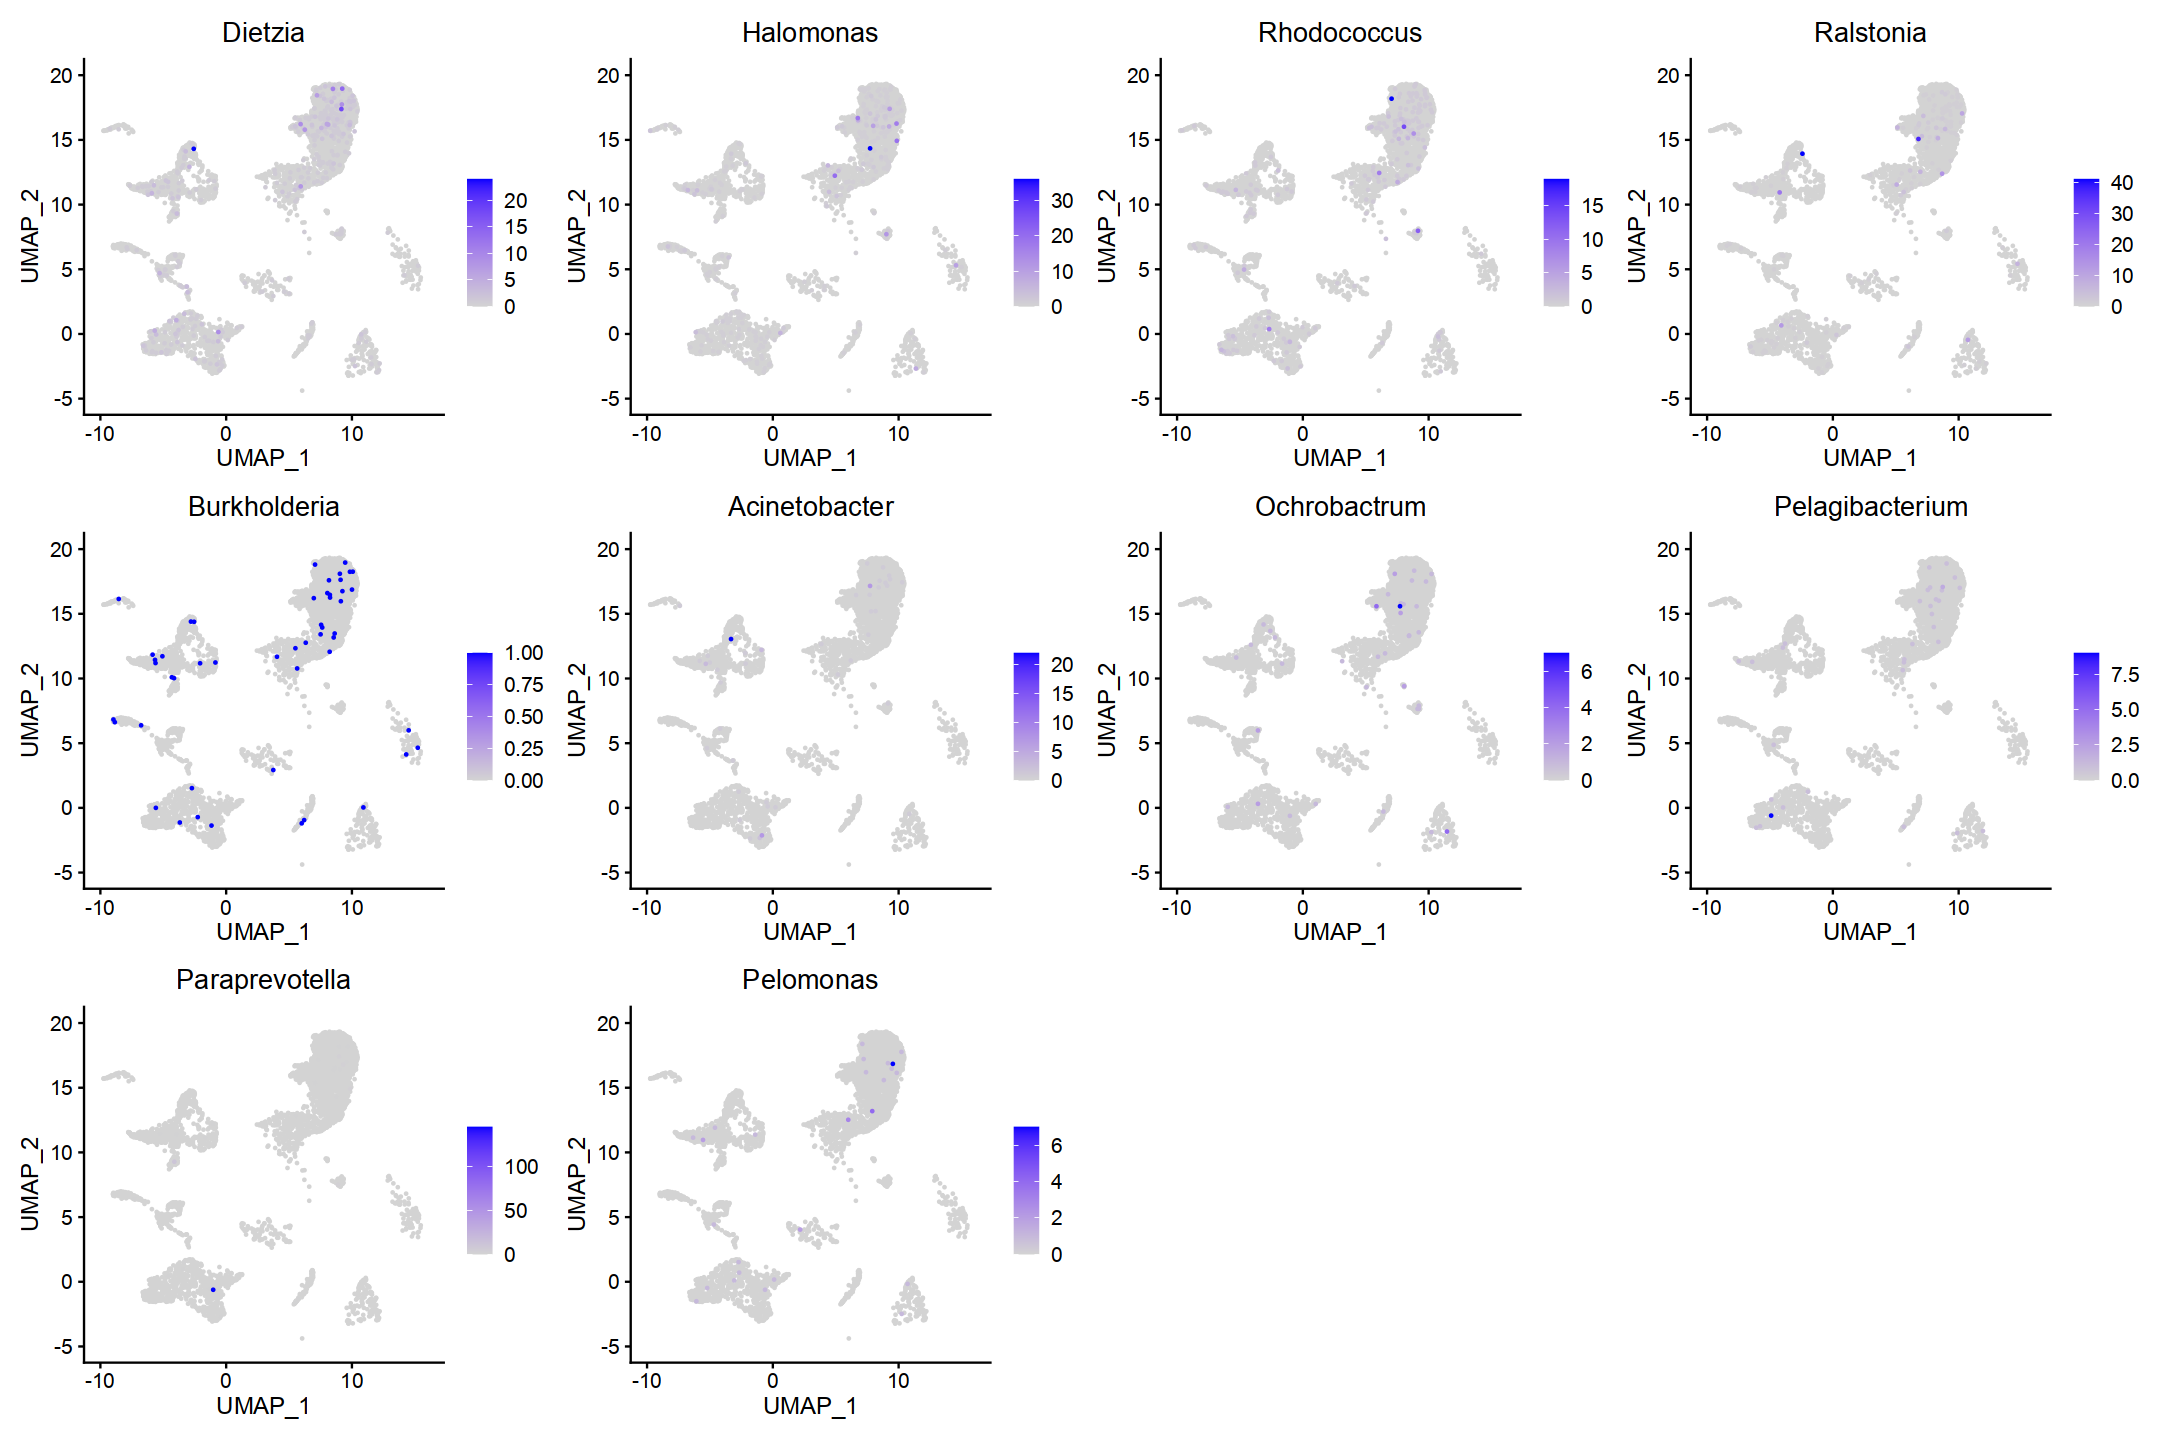

In [5]:
# top10 detect genus
top10_detect_genus <- names(sort(colSums(df_genus > 0), decreasing = T)[1:10])

options(repr.plot.height = 12, repr.plot.width =18)
FeaturePlot(data_seurat, features = top10_detect_genus, order = T)

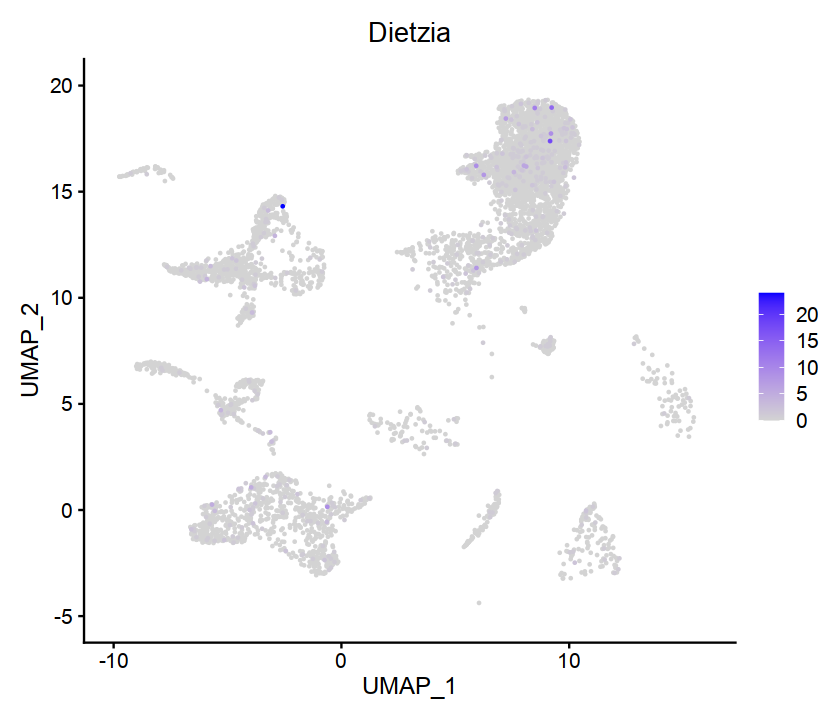

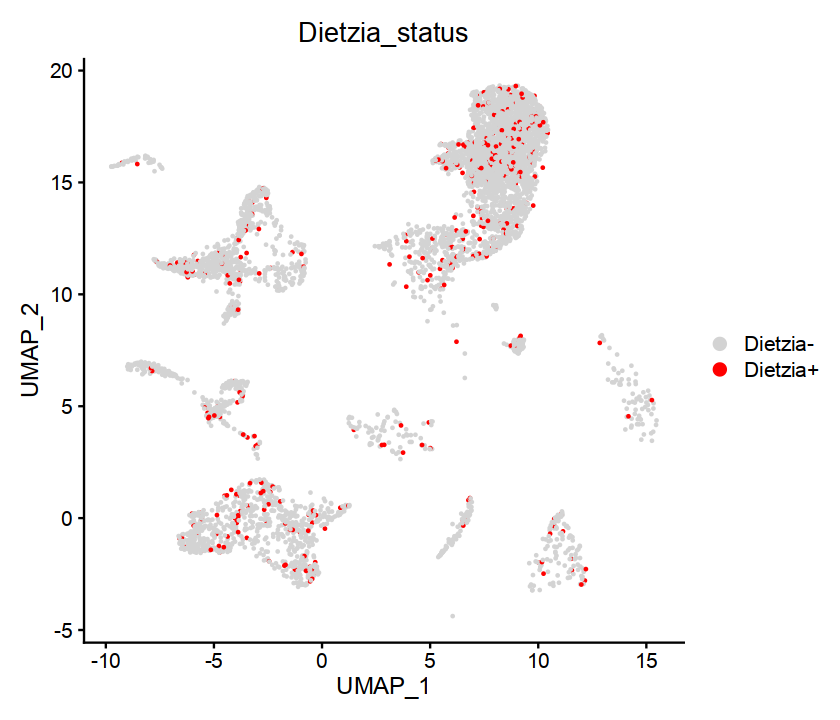

In [6]:
# top1 genus
options(repr.plot.height = 6, repr.plot.width =7)
FeaturePlot(data_seurat, features = top10_detect_genus[1], order = T)

# top1 genus status
data_seurat$Dietzia_status <- ifelse( data_seurat$Dietzia >0 , "Dietzia+", "Dietzia-")
DimPlot(data_seurat, group.by = "Dietzia_status", cols = c("lightgrey", "red"))

In [7]:
sessionInfo()

R version 4.1.1 (2021-08-10)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /SGRNJ01/Public/Software/conda_env/r4.1_env/lib/libopenblasp-r0.3.21.so

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] forcats_1.0.0      stringr_1.5.0      dplyr_1.1.3        purrr_1.0.1       
 [5] readr_2.1.4        tidyr_1.3.0        tibble_3.2.1       ggplot2_3.4.1     
 [9] tidyverse_1.3.2    SeuratObject_4.0.4 Seurat_4.1.0      

loaded via a namespace (and not attached):
  [1] readxl_1.4.2       